# UTS II4013 Data Analytics
## Personalized Data Auditor & Decision Analyst

**Nama:** Aliya Harta Ary Utama   
**NIM:**  18223081  
**Kelas:**  K01  

### Pernyataan Keaslian
Saya menyatakan bahwa seluruh analisis pada notebook ini dikerjakan secara mandiri berdasarkan dataset yang dihasilkan dari NIM saya sendiri. Setiap keputusan analitik dijelaskan dengan alasan yang dapat saya pertanggungjawabkan.

## A. Tujuan Analisis

Jelaskan secara singkat:
1. Apa tujuan analisis Anda?  

    **Jawab** : Tujuan analisis yang saya lakukan adalah untuk menganalisis faktor-faktor apa saja yang mempengaruhi konsumsi energi pada *smart campus*, seperti temperature, humidity, student_count, device_usage, dan day_type. Selanjutnya, akan dibuat model prediktif dengan variabel yang telah diidentifikasi tersebut untuk memperkirakan konsumsi energi pada masa mendatang.

2. Apa target variabel yang akan dipelajari?  

    **Jawab** : Target variabel yang akan dipelajari / dianalisis adalah **energy_consumtion** yang merupakan variabel *continue*, dengan variable faktor seperti temperature, humidity, student_count, device_usage dan day_type.  

3. Keputusan apa yang ingin didukung oleh analisis ini?  

    **Jawab**: Melalui hasil analisis yang dilakukan diharapkan dapat membantu kampus untuk mengoptimalkan penggunaan energi, seperti kapan harus mematikan lampu dengan kondisi yang diidentifikasi sebagai saat yang paling boros energi.

## B. Import Library
Jalankan sel berikut sebelum memulai analisis.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from scipy import stats

plt.rcParams["figure.figsize"] = (8, 5)

## C. Membuat Dataset Personal

Tuliskan NIM Anda dan jalankan generator dataset.  
Pastikan dataset yang dianalisis berasal dari NIM Anda sendiri.

In [ ]:
# Isi dengan NIM masing-masing
nim = "18223081"

In [ ]:
def generate_dataset(nim, n_samples=500):
    np.random.seed(int(nim[-3:]))

    noise_level = int(nim[1])       # digit ke-2
    missing_pattern = int(nim[3])   # digit ke-4
    bias_factor = int(nim[-1])      # digit terakhir

    timestamp = pd.date_range(start="2024-01-01", periods=n_samples, freq="h")

    temperature = 25 + 5 * np.sin(np.linspace(0, 10, n_samples)) + np.random.randn(n_samples)
    humidity = 60 + 10 * np.cos(np.linspace(0, 5, n_samples)) + np.random.randn(n_samples)

    student_count = np.random.randint(50, 500, n_samples)
    device_usage = student_count * np.random.uniform(0.5, 1.5, n_samples)

    day_type = np.where(pd.Series(timestamp).dt.dayofweek < 5, "weekday", "weekend")

    energy = (
        0.5 * temperature +
        0.3 * humidity +
        0.01 * student_count +
        0.02 * device_usage +
        bias_factor * 2
    )

    # Komponen non-linear
    energy += 5 * np.sin(student_count / 100)

    # Noise berdasarkan NIM
    energy += np.random.randn(n_samples) * noise_level

    df = pd.DataFrame({
        "timestamp": timestamp,
        "temperature": temperature,
        "humidity": humidity,
        "student_count": student_count,
        "device_usage": device_usage,
        "day_type": day_type,
        "energy_consumption": energy
    })

    # Inject missing values berdasarkan pola NIM
    if missing_pattern % 3 == 0:
        df.loc[df.sample(frac=0.1, random_state=1).index, "temperature"] = np.nan
    elif missing_pattern % 3 == 1:
        df.loc[df.sample(frac=0.1, random_state=1).index, "humidity"] = np.nan
    else:
        df.loc[df.sample(frac=0.1, random_state=1).index, "student_count"] = np.nan

    # Inject outliers pada target
    outlier_idx = np.random.choice(df.index, size=int(0.05 * n_samples), replace=False)
    df.loc[outlier_idx, "energy_consumption"] *= (1 + bias_factor / 5)

    return df

In [ ]:
df = generate_dataset(nim)
df.head()

,timestamp,temperature,humidity,student_count,device_usage,day_type,energy_consumption
0,2024-01-01 00:00:00,23.640100,68.523538,291.0,205.131092,weekday,42.886812
1,2024-01-01 01:00:00,23.864792,69.688595,142.0,101.280096,weekday,42.226102
2,2024-01-01 02:00:00,25.260276,69.563924,185.0,214.646799,weekday,51.008342
3,2024-01-01 03:00:00,23.645778,68.785873,253.0,134.578153,weekday,42.898646
4,2024-01-01 04:00:00,25.424041,70.388236,NaN,227.939399,weekday,42.311088


In [ ]:
df.shape

(500, 7)

In [ ]:
# Simpan dataset personal agar mudah dilampirkan saat pengumpulan
output_csv = f"dataset_UTS_{nim}.csv"
df.to_csv(output_csv, index=False)
print(f"Dataset tersimpan sebagai: {output_csv}")

Dataset tersimpan sebagai: dataset_UTS_18223081.csv


## D. Data Understanding

Lakukan pemeriksaan awal terhadap dataset:
1. Ukuran data
2. Nama variabel
3. Tipe data
4. Ringkasan statistik
5. Dugaan awal masalah kualitas data

**Tulis interpretasi Anda setelah kode dijalankan.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   timestamp           500 non-null    datetime64[ns]
 1   temperature         500 non-null    float64       
 2   humidity            500 non-null    float64       
 3   student_count       450 non-null    float64       
 4   device_usage        500 non-null    float64       
 5   day_type            500 non-null    object        
 6   energy_consumption  500 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 27.5+ KB


In [ ]:
df.describe(include="all")

,timestamp,temperature,humidity,student_count,device_usage,day_type,energy_consumption
count,500,500.000000,500.000000,450.000000,500.000000,500,500.000000
unique,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,weekday,NaN
freq,NaN,NaN,NaN,NaN,NaN,360,NaN
mean,2024-01-11 09:30:00,25.894762,58.083967,269.708889,268.901451,NaN,40.871242
min,2024-01-01 00:00:00,17.434045,47.738928,50.000000,30.996038,NaN,11.222143
25%,2024-01-06 04:45:00,22.801649,51.884793,155.250000,147.897985,NaN,34.494957
50%,2024-01-11 09:30:00,26.367746,56.914587,269.000000,254.813387,NaN,40.649946
75%,2024-01-16 14:15:00,28.876301,63.544344,386.000000,356.527237,NaN,46.734755
max,2024-01-21 19:00:00,32.518225,71.572752,497.000000,706.179185,NaN,81.076855


In [ ]:
print(df.isna().sum())
print(" ")
print(df['day_type'].value_counts())

timestamp              0
temperature            0
humidity               0
student_count         50
device_usage           0
day_type               0
energy_consumption     0
dtype: int64
 
day_type
weekday    360
weekend    140
Name: count, dtype: int64


### Interpretasi Awal
Jawab pertanyaan berikut:

- Ukuran data adalah terdapat 500 row dengan 7 fitur didalamnya. Dengan fitur-fitur tersebut adalah **timestamp, temperature, humidity	student_count, device_usage, day_type, energy_consumption**

- Variabel mana yang numerik dan kategorikal?  
  **Jawab** : Variabel yang numerik yang bertipe **float64** adalah `temperature` yang menjelaskan data suhu, `humidity` yang menjelaskan data kelembapan, `student_count` yang menjelaskan jumlah mahasiswa, `device_usage` yang menjelaskan jumlah perangkat yang digunakan, `energy_consumption` yang menjelaskan jumlah konsumsi energi.   
  Sedangkan, untuk variabel kategorikal yang bertipe **object** adalah `day_type` yang menjelaskan jenis hari (*weekend / weekday*).   

- Apakah ada missing value?  
  **Jawab** : Seperti yang terlihat di atas, terdapat 50 missing values pada variabel `student_count`.  

- Apakah ada nilai yang tampak tidak wajar?  
  **Jawab** : Berdasarkan analisis statistik yang dilakukan, hampir semua nilai terlihat normal, namun jika dilihat pada variabel `device_usage` dan `energy_consumption` nilai max mereka 2x lipat dari Q3. Namun, identifikasi nilai yang tidak wajar ini, harus dilakukan lebih lanjut untuk memastikan kebenarannya.

- Apakah target variabel tampak cocok untuk regresi?  
  **Jawab** : Target variabel energy_consumption sudah cocok untuk dilakukan regresi, karena bersifat kontinu, dan memiliki rentang yang cukup besar, namun masih terdapat outlier yang tampak.

## E. Audit Kualitas Data

Lakukan audit terhadap:
1. Missing values
2. Outliers
3. Ketidakkonsistenan format / tipe data
4. Potensi bias

In [ ]:
# Persentase missing value
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False)

,0
student_count,10.0
temperature,0.0
timestamp,0.0
humidity,0.0
device_usage,0.0
day_type,0.0
energy_consumption,0.0


In [ ]:
def detect_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), lower, upper, mask

outlier_summary = []
for col in ["temperature", "humidity", "student_count", "device_usage", "energy_consumption"]:
    count, lower, upper, mask = detect_outliers_iqr(df[col].dropna())
    outlier_summary.append({
        "column": col,
        "outlier_count": int(count),
        "lower_bound": float(lower),
        "upper_bound": float(upper)
    })

pd.DataFrame(outlier_summary)

,column,outlier_count,lower_bound,upper_bound
0,temperature,0,13.689671,37.988279
1,humidity,0,34.395468,81.033670
2,student_count,0,-190.875000,732.125000
3,device_usage,4,-165.045893,669.471114
4,energy_consumption,6,16.135259,65.094453


### Hasil Audit
Isi uraian singkat:
- Variabel bermasalah:
- Jenis masalah:
- Dampak potensial terhadap analisis:  

**Jawab** :   
Berdasarkan hasil audit kualitas data :  
1. Terdapat variabel bermasalah yaitu `student_count` yang memiliki **missing value sebesar 10%** dari total keseluruhan data, hal ini berpotensi memberikan hasil **bias** terhadap hasil analisis dan prediksi model.  
2. Terdapat variabel bermasalah berikutnya adalah `device_usage` dan `energy_consumption` yang memiliki **outlier** berjumlah 4 dan 6, hal ini berpotensi membuat prediksi menjadi **kurang akurat** karena akan merusak nilai R2 & garis regresi.   

3. Seluruh data memiliki tipe yang konsisten, sehingga dapat disimpulkan bahwa **tidak ada inkonsistensi data** pada dataset ini.

## F. Penanganan Missing Value

Pilih satu metode imputasi yang menurut Anda paling tepat, misalnya:
- Mean
- Median
- Interpolation
- Metode lain

Jangan hanya menjalankan metode. Jelaskan:
1. Mengapa metode itu dipilih?
2. Mengapa metode lain tidak dipilih?

In [ ]:
#Imputasi Median
df_median = df.copy()
median_val = df_median['student_count'].median()
df_median['student_count'] = df_median['student_count'].fillna(median_val)

#Imputasi Mean
df_mean = df.copy()
mean_val = df_mean['student_count'].mean()
df_mean['student_count'] = df_mean['student_count'].fillna(mean_val)

#Perbandingan
comparison = pd.DataFrame({
    'Metode': ['Original', 'Median Imputation', 'Mean Imputation'],
    'Mean': [
        df['student_count'].dropna().mean(),
        df_median['student_count'].mean(),
        df_mean['student_count'].mean()
    ],
    'Std': [
        df['student_count'].dropna().std(),
        df_median['student_count'].std(),
        df_mean['student_count'].std()
    ],
    'Skewness': [
        df['student_count'].dropna().skew(),
        df_median['student_count'].skew(),
        df_mean['student_count'].skew()
    ]
})
print(comparison.to_string(index=False))

           Metode       Mean        Std  Skewness
         Original 269.708889 130.932571  0.037630
Median Imputation 269.638000 124.199896  0.041371
  Mean Imputation 269.708889 124.199714  0.039652


In [ ]:
df_clean = df.copy()

for col in ["student_count"]:
    if df_clean[col].isna().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing value setelah imputasi:")
print(df_clean.isna().sum())

Missing value setelah imputasi:
timestamp             0
temperature           0
humidity              0
student_count         0
device_usage          0
day_type              0
energy_consumption    0
dtype: int64


### Justifikasi Missing Value Handling
Saya melakukan imputasi `median` pada missing value, karena seperti yang kita lihat bahwa nilai pada **student_count**, memiliki distribusi yang hampir uniform antara 50-497, sehingga nilai imputasi akan lebih merata sebagai nilai sentral, dan data tidak terlalu terdistorsi.  

Alasan mengapa tidak melakukan imputasi **mean** adalah karena walaupun nilai mean dan median hampir setara, namun jika dilihat dari perubahan std original-mean dan original-median, terlihat bahwa nilai original-median yang lebih kecil, artinya data lebih stabil dengan imputasi median daripada mean.  

Selanjutnya, alasan tidak menggunakan metode imputasi **interpolasi** karena imputasi ini biasanya dilakukan di data yang timeseries agar nilai imputasi setara dengan data sebelum dan sesudah. Namun, karena student_count ini tidak tipe data time series, maka imputasi ini kurang cocok.  

Selanjutnya, alasan tidak menggunakan metode **penghapusan row** adalah karena missing value di student_count ada sebanyak 50 baris, dimana penghapusan sekitar 10% baris dari dataset akan mempengaruhi hasil yang didapatkan.


## G. Outlier Handling dan Transformasi

Tentukan apakah outlier:
- Dipertahankan
- Dibatasi
- Dihapus
- Ditangani dengan model robust

Lalu tentukan apakah data perlu scaling atau transformasi.

In [ ]:
q1 = df_clean["energy_consumption"].quantile(0.25)
q3 = df_clean["energy_consumption"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

n_outliers = ((df_clean['energy_consumption'] < lower) | (df_clean['energy_consumption'] > upper)).sum()
print(f"Jumlah outlier terdeteksi (IQR method): {n_outliers}")
print(f"Lower bound: {lower:.3f} | Upper bound: {upper:.3f}")

Jumlah outlier terdeteksi (IQR method): 6
Lower bound: 16.135 | Upper bound: 65.094


In [ ]:
df_clean["energy_capped"] = df_clean["energy_consumption"].clip(lower=lower, upper=upper)
df_clean["target"] = df_clean["energy_capped"]

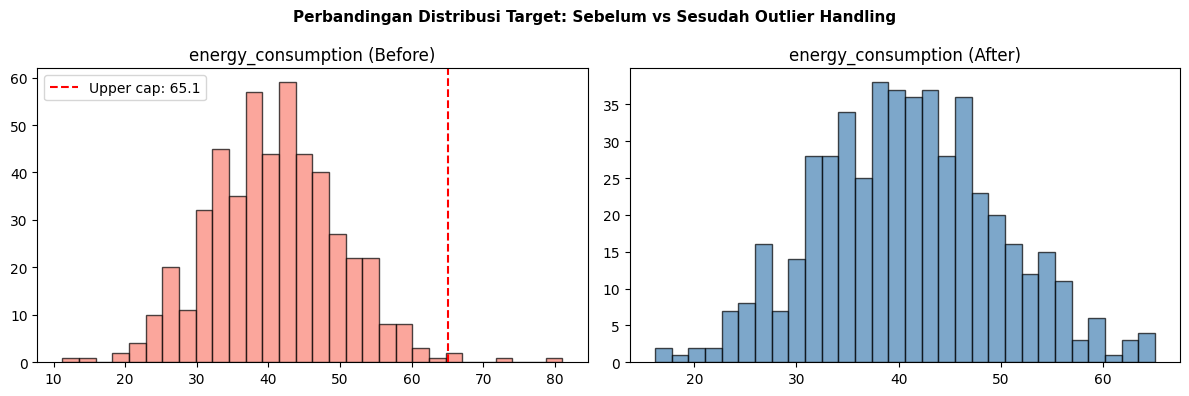


Statistik sebelum capping: mean=40.871, std=9.094
Statistik sesudah capping: mean=40.833, std=8.896


In [ ]:
df_clean["energy_capped"] = df_clean["energy_consumption"].clip(lower=lower, upper=upper)
df_clean["target"] = df_clean["energy_capped"]

# Visualisasi perbandingan sebelum vs sesudah capping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_clean['energy_consumption'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('energy_consumption (Before)')
axes[0].axvline(upper, color='red', linestyle='--', label=f'Upper cap: {upper:.1f}')
axes[0].legend()

axes[1].hist(df_clean['target'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title('energy_consumption (After)')
plt.suptitle('Perbandingan Distribusi Target: Sebelum vs Sesudah Outlier Handling', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nStatistik sebelum capping: mean={df_clean['energy_consumption'].mean():.3f}, std={df_clean['energy_consumption'].std():.3f}")
print(f"Statistik sesudah capping: mean={df_clean['target'].mean():.3f}, std={df_clean['target'].std():.3f}")

### Justifikasi Outlier dan Transformasi
- Apakah outlier dihapus atau dipertahankan?
- Mengapa?
- Apa dampaknya terhadap model?

Jawaban:
- Outlier tidak dihapus, tapi dipertahankan dengan cara diseragamkan nilainya dengan metode winsorization menggunakan batas IQR (Q3 + 1.5×IQR). Alasannya adalah karena outlier ini mungkin menggambarkan kondisi spesial seperti event besar kampus yang mana pastinya energi yang digunakan akan sangat besar, sehingga metode winsorization mempertahankan baris tersebut sambil membatasi pengaruh nilainya yang ekstrem. Selanjutnya, tidak digunakan metode penghapusan row karena informasi" penting juga akan terhapus, sehingga analisis model tidak akurat.  
Dampaknya pada model adalah standar deviasi target menurun setelah capping, sehingga data bersifat lebih homogen.  
- Scaling & Transformasi  
Scaling tidak perlu dilakukan karena ukuran data antar variabel tidak terlalu jauh, dan juga karena model yang akan kita gunakan nanti tidak dipengaruhi skala tetapi koefisien yang secara otomatis menyesuaikan skala fitur.
Transformasi juga tidak dilakukan karena jika menggunakan model linear tidak dipengaruhi skala fitur, karena model ini bekerja dengan mencari koefisien.

## H. Visualisasi Data

Buat minimal:
1. Histogram target
2. Scatter plot fitur vs target
3. Visualisasi hubungan dua fitur

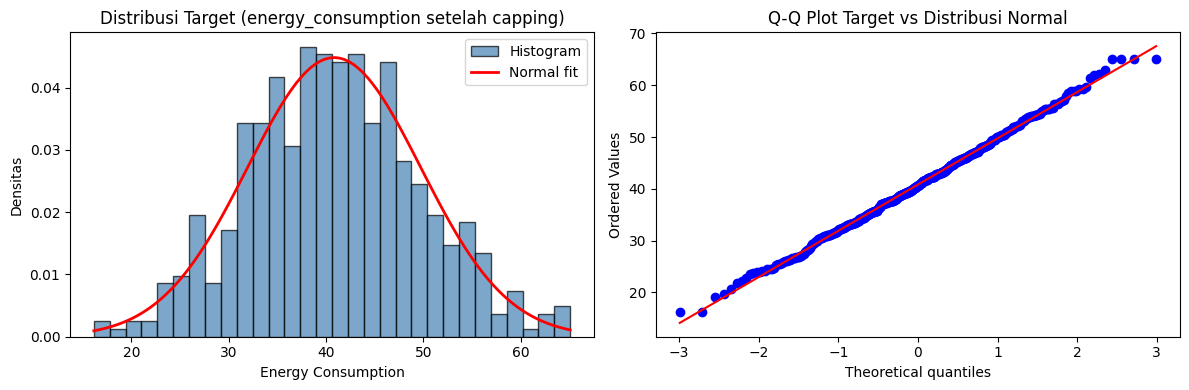

In [ ]:
# Histogram target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_clean['target'], bins=30, density=True, color='steelblue', edgecolor='black', alpha=0.7, label='Histogram')
mu, std = df_clean['target'].mean(), df_clean['target'].std()
xmin, xmax = df_clean['target'].min(), df_clean['target'].max()
x = np.linspace(xmin, xmax, 100)
axes[0].plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Normal fit')
axes[0].set_title('Distribusi Target (energy_consumption setelah capping)')
axes[0].set_xlabel('Energy Consumption')
axes[0].set_ylabel('Densitas')
axes[0].legend()

# Q-Q Plot
stats.probplot(df_clean['target'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot Target vs Distribusi Normal')

plt.tight_layout()
plt.show()

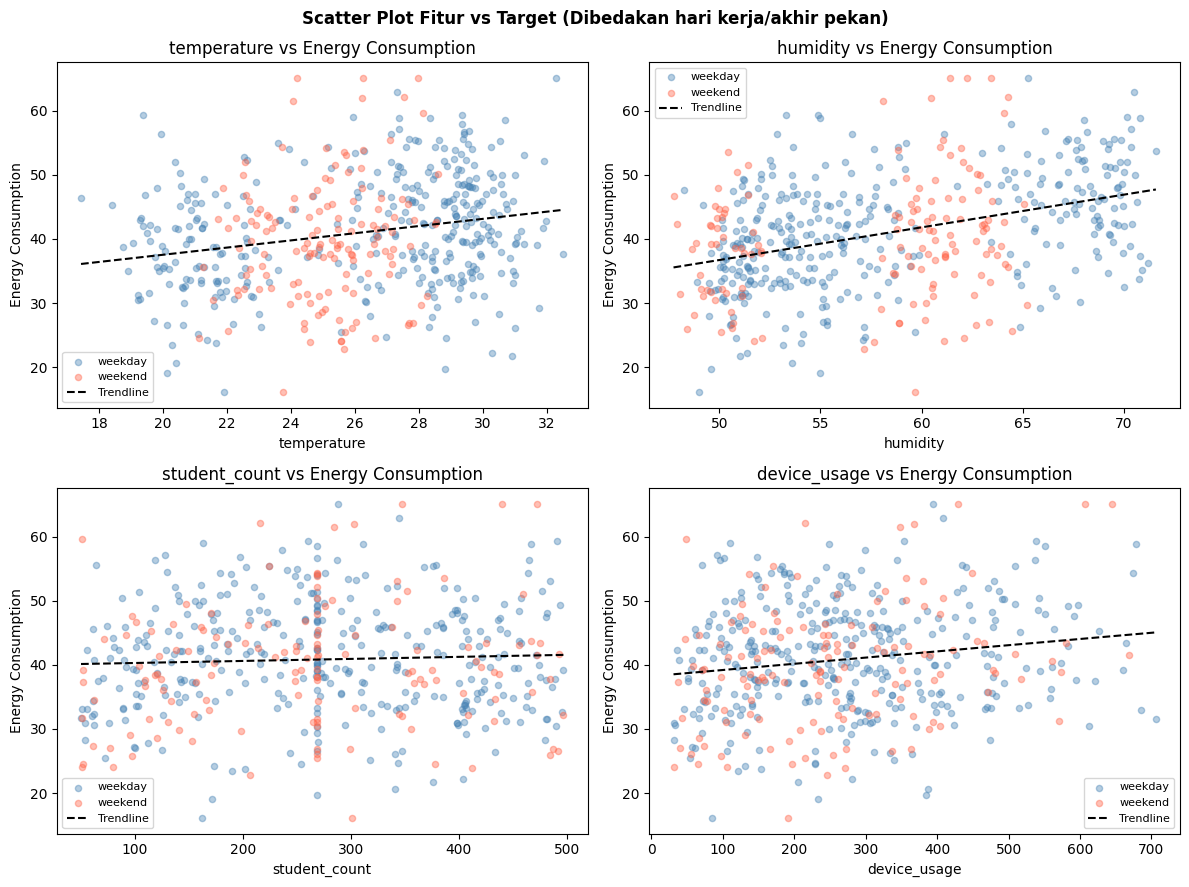

In [ ]:
# Scatter plot setiap fitur vs target
features = ["temperature", "humidity", "student_count", "device_usage"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

colors = {'weekday': 'steelblue', 'weekend': 'tomato'}
for i, feat in enumerate(features):
    for day, color in colors.items():
        mask = df_clean['day_type'] == day
        axes[i].scatter(df_clean.loc[mask, feat], df_clean.loc[mask, 'target'],
                        alpha=0.4, s=20, color=color, label=day)
    z = np.polyfit(df_clean[feat].dropna(), df_clean['target'][df_clean[feat].notna()], 1)
    p = np.poly1d(z)
    xr = np.linspace(df_clean[feat].min(), df_clean[feat].max(), 100)
    axes[i].plot(xr, p(xr), 'k--', lw=1.5, label='Trendline')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Energy Consumption')
    axes[i].set_title(f'{feat} vs Energy Consumption')
    axes[i].legend(fontsize=8)

plt.suptitle('Scatter Plot Fitur vs Target (Dibedakan hari kerja/akhir pekan)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

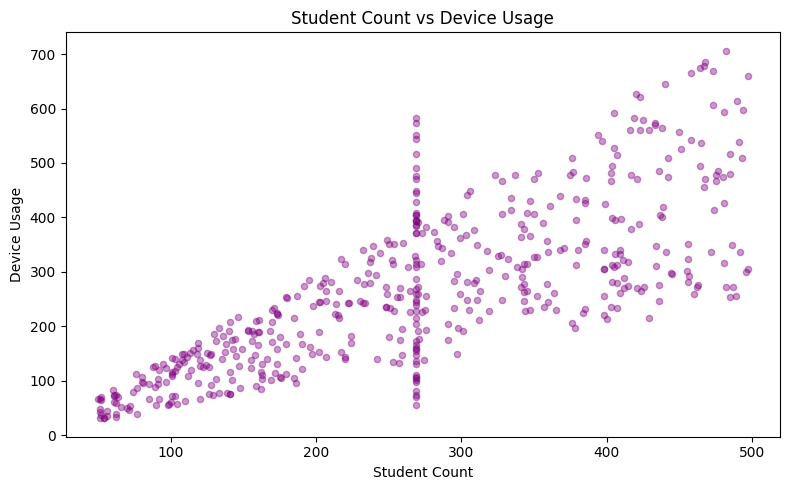

In [ ]:
# Scatter plot student_count vs device_usage
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['student_count'], df_clean['device_usage'], alpha=0.4, s=20, color='purple')
plt.title('Student Count vs Device Usage')
plt.xlabel('Student Count')
plt.ylabel('Device Usage')
plt.tight_layout()
plt.show()

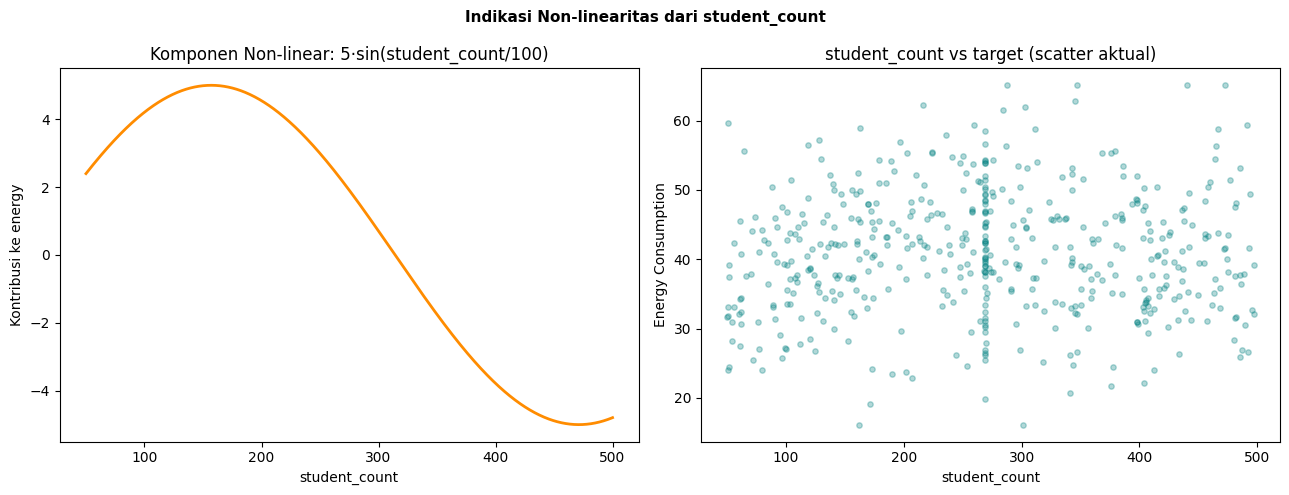

In [ ]:
# Visualisasi non-linearitas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc_vals = np.linspace(50, 500, 1000)
nonlinear_component = 5 * np.sin(sc_vals / 100)
axes[0].plot(sc_vals, nonlinear_component, color='darkorange', lw=2)
axes[0].set_title('Komponen Non-linear: 5·sin(student_count/100)')
axes[0].set_xlabel('student_count')
axes[0].set_ylabel('Kontribusi ke energy')

axes[1].scatter(df_clean['student_count'], df_clean['target'], alpha=0.3, s=15, color='teal')
axes[1].set_title('student_count vs target (scatter aktual)')
axes[1].set_xlabel('student_count')
axes[1].set_ylabel('Energy Consumption')
plt.suptitle('Indikasi Non-linearitas dari student_count', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretasi Visualisasi
Jawab:
- Apakah distribusi target simetris, skewed, atau memiliki ekor panjang?
- Fitur mana yang tampak memiliki hubungan kuat dengan target?
- Apakah ada pola non-linear?
- Apakah ada indikasi outlier atau cluster?

Jawaban :   

- Setelah dilakukan capping pada energy_consumption, terlihat bahwa distribusi data lebih mendekati normal, yang ditunjukkan dengan histogram berbentuk lonceng tersebut. Namun Q-Q plot menunjukkan sedikit menyimpang di ekor kiri yang artinya distribusi masih tidak sepenuhnya normal, tetapi cukup baik.  
- Fitur **temperature** dan **humidity** terlihat memiliki hubungan yang jelas, yaitu ketika semakin tinggi suhu, semakin tinggi konsumsi energi. Trendline relatif linear. Untuk fitur **student_count** dan **device_usage**, terlihat titik" yang sangat menyebar, dimana artinya fitur ini memiliki hubungan sangat lemah dengan target.  
- Scatter plot **student_count** vs **energy_consumption** menunjukkan spread yang tidak homogen, artinya model linear murni tidak akan menangkap keseluruh *pola non linear* ini.  
- Tidak ada indikasi outlier, karena outlier pada energy_consumption sudah ditangani pada part sebelumnya, dan juga tidak ada indikasi clustering juga, karena hanya menemukan 1 cluster besar.

## I. Encoding Variabel Kategorikal

Jika variabel kategorikal digunakan dalam model, lakukan encoding yang sesuai.

In [ ]:
df_model = df_clean.copy()
df_model = pd.get_dummies(df_model, columns=["day_type"], drop_first=True)
df_model.head()

,timestamp,temperature,humidity,student_count,device_usage,energy_consumption,energy_capped,target,day_type_weekend
0,2024-01-01 00:00:00,23.640100,68.523538,291.0,205.131092,42.886812,42.886812,42.886812,False
1,2024-01-01 01:00:00,23.864792,69.688595,142.0,101.280096,42.226102,42.226102,42.226102,False
2,2024-01-01 02:00:00,25.260276,69.563924,185.0,214.646799,51.008342,51.008342,51.008342,False
3,2024-01-01 03:00:00,23.645778,68.785873,253.0,134.578153,42.898646,42.898646,42.898646,False
4,2024-01-01 04:00:00,25.424041,70.388236,269.0,227.939399,42.311088,42.311088,42.311088,False


### Justifikasi Encoding

Saya menggunakan metode One Hot Encoding dengan drop_first=True. Karena variabel day_type hanya memiliki kolom antara weekend / weekday, maka tidak diperlukan label encoding karena tidak ada urutan di kategori ini dan menggunakan drop_first=True, sehingga langsung mengelompokkan day_type_weekend = 1, dan day_type_weekday = 0. Selanjutnya setelah fitur day_type_weekend ini sudah berubah menjadi 1/0, maka fitur ini juga dapat digunakan pada analisis dan pembangunan model nantinya.

## J. Analisis Korelasi

Lakukan:
1. Korelasi Pearson antar variabel numerik
2. Interpretasikan hasilnya
3. Jelaskan keterbatasannya

In [ ]:
corr_cols = ["temperature", "humidity", "student_count", "device_usage", "day_type_weekend", "target"]
corr_matrix = df_model[corr_cols].corr()
print("Matriks Korelasi Pearson")
corr_matrix

Matriks Korelasi Pearson


,temperature,humidity,student_count,device_usage,day_type_weekend,target
temperature,1.000000,0.319448,-0.038323,-0.026523,-0.150919,0.217693
humidity,0.319448,1.000000,0.035826,0.033802,-0.061993,0.382827
student_count,-0.038323,0.035826,1.000000,0.773324,-0.048190,0.044382
device_usage,-0.026523,0.033802,0.773324,1.000000,-0.064300,0.162019
day_type_weekend,-0.150919,-0.061993,-0.048190,-0.064300,1.000000,-0.079641
target,0.217693,0.382827,0.044382,0.162019,-0.079641,1.000000


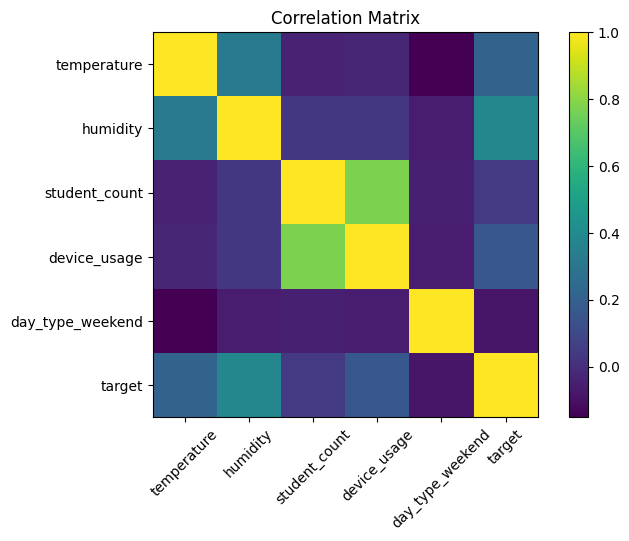

In [ ]:
plt.imshow(corr_matrix, interpolation="nearest")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

### Interpretasi Korelasi
Jawab:
- Fitur mana yang paling berkorelasi dengan target?
Berdasarkan analisis korelasi yang telah dilakukan dapat terlihat nilai yang berhubungan paling besar dengan target adalah humidity	(0.382827) dan temperature (0.217693), serta pada heatmap terlihat bahwa humidity memilki warna hijau dan temperature biru yang mendekati warna terang (target). Hal ini menunjukkan bahwa di antara semua variabel yang ada, humidity dan temperature memiliki hubungan linear terkuat dengan energy_consumption.  

- Apakah korelasinya positif atau negatif?
Jika dilihat pada heatmap dan analisis pearson, terlihat bahwa fitur temperature, humidity, student_count, device_usage memiliki nilai positif dan spektrum warna hijau / biru. Sehingga, hal ini menunjukkan bahwa fitur dan target akan berkorelasi positif, yang artinya ketika nilai fitur-fitur ini naik, maka target cenderung naik.  
Selanjutnya, jika dilihat pada fitur day_type_weekend terlihat bahwa nilai adalah negatif dan warna menjadi ungu tua, yang artinya fitur ini berkorelasi negatif. Sehingga dapat diinterpretasikan bahwa, jika weekend maka konsumsi energi di kampus akan turun.  

- Apakah ada pasangan fitur yang saling berkorelasi tinggi?  
Menurut hasil analisis korelasi dengan pearson dan heatmap, terlihat bahwa ada fitur yang saling berkorelasi tinggi, yaitu student_count dan device_usage. Terlihat bahwa nilai korelasi mencapai 0.77 dan warna spektrum hijau terang. Dimana artinya kedua fitur ini bergerak bersama, ketika jumlah mahasiswa banyak, maka jumlah perangkat yang digunakan juga akan meningkat.  

- Apakah korelasi cukup untuk menyimpulkan sebab-akibat?  
Tidak bisa, karena korelasi hanya mengukur tentang seberapa kedua fitur akan bergerak bersama, namun, untuk sebab-akibat perlu dilakukan eksperimen lebih lanjut. Pada data ini, tidak bisa disebutkan secara eksplisit bahwa kelembapan akan menyebabkan pemborosan energi, namun mungkin terdapat hal yang dilakukan ketika kelembapan tinggi yang menyebabkan pemborosan energi.  

- Analisis Pearson dan Heatmap ini hanya menangkap nilai linear, sehingga apabila terdapat nilai non linear tidak akan bisa dijelaskan melalui analisis pearson ini. Selanjutnya analisis ini hanya bisa mengukur hubungan 2 variabel saja, sehingga tidak bisa mengukur hubungan multi variabel yang mungkin saja memiliki korelasi lebih tinggi apabila beberapa fitur digabung.

## K. Persiapan Data untuk Pemodelan Regresi

Pilih fitur input dan target.  
Jelaskan mengapa fitur tertentu digunakan atau tidak digunakan.

In [ ]:
feature_cols = ["temperature", "humidity", "student_count", "device_usage", "day_type_weekend"]
X = df_model[feature_cols]
y = df_model["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)

Ukuran X_train: (400, 5)
Ukuran X_test : (100, 5)


### Justifikasi Pemilihan Fitur
Saya memilih fitur : temperature, humidity, student_count, device_usage, dan day_type_weekend. Dan target : energy_consumption
Alasannnya karena pada analisis korelasi sebelumnya temperature dan humidity memiliki korelasi yang cukup tinggi dengan target, dimana hal ini menginterpretasikan lingkungan berpengaruh terhadap konsumsi energi. Selanjutnya student_count digunakan karena kepadatan kampus berpengaruh pada beban listrik. Pada device_usage merepresentasikan penggunaan perangkat elektronik, serta day_type_weekend untuk menganalisis pola antara weekday dan weekend.  
Variabel target adalah energy_consumption karena kita akan mengukur / menganalisis hasil dari variabel ini.

## L. Model 1 – Linear Regression

Bangun model baseline dengan regresi linear.

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred_lin = lin_reg.predict(X_test)

In [ ]:
mae_lin = mean_absolute_error(y_test, y_pred_lin)
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
r2_lin = r2_score(y_test, y_pred_lin)

print("Linear Regression Performance")
print("MAE :", mae_lin)
print("MSE :", mse_lin)
print("RMSE:", rmse_lin)
print("R2  :", r2_lin)

Linear Regression Performance
MAE : 6.442637619974831
MSE : 65.68532935325702
RMSE: 8.10464862614395
R2  : 0.23223406091815046


In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
})
coef_df

,feature,coefficient
0,temperature,0.268297
1,humidity,0.410548
2,student_count,-0.010848
3,device_usage,0.017163
4,day_type_weekend,-0.922517


### Interpretasi Model Linear
Jawab:
- Apa arti koefisien masing-masing fitur?
Koefisien dalam model linear diartikan sebagai besarnya perubahan pada energy_consumption untuk setiap kenaikan satu unit pada fitur terkait, dengan asumsi fitur lainnya tetap. Selanjutnya, pada :
  1. humidity & temperature: Memiliki koefisien yang positif dan dua terbesar, dimana untuk setiap kenaikan derajat suhu / persentase kelembaban berkontribusi langsung pada peningkatan konsumsi energi.  
  2. device_usage: Memiliki koefisien yang positif juga, hal ini mencerminkan penggunaan daya aktif dari perangkat yang menyala.  
  3. student_count: Memiliki nilai negatif, karena pengaruhnya sudah tertangkap lebih dulu pada device_usage, dan komponen non-linear sinusoidal tidak bisa ditangkap oleh OLS. Hal ini mewakili beban dasar aktivitas manusia.  
  4. day_type_weekend: Memiliki nilai negatif, menunjukkan bahwa konsumsi energi pada weekend lebih rendah dari weekday. Karena menggunakan One-Hot Encoding, koefisien negatifnya berarti selisih rata-rata penurunan energi pada akhir pekan dibandingkan hari kerja.

- Fitur mana yang paling dominan?  
Berdasarkan hasil koefisien, maka fitur humidity adalah yang paling dominan karena memiliki nilai koefisien terbesar. Hal ini menunjukkan bahwa fluktuasi energi di kampus sangat sensitif terhadap perubahan kelembaban.

- Apakah tanda koefisien sesuai dugaan awal?  
Beberapa fitur memiliki tanda koefisien yang sudah sesuai dengan dugaan awal seperti humidity, temperature, dan penggunaan perangkat bertanda positif karena secara fisik menambah beban energi. Namun, terdapat koefisien negatif pada student_count karena nilai pengaruhnya terbagi dengan device_usage, sehingga ia menjadi bernilai negatif. Dan, pada day_type_weekend juga bernilai negatif seperti pada dugaan awal.

- Apakah performa model cukup baik?  
Apabila dilihat berdasarkan hasil MAE : 6.442637619974831, MSE : 65.68532935325702, RMSE: 8.10464862614395, R2 : 0.23223406091815046, dimana terlihat nilai R2 rendah yaitu hanya sekitar 0.23, dimana model hanya dapat menjelaskan variasi sebesar 23% dan sekitar 76% lainnya dipengaruhi oleh faktor lain yang belum tertangkap oleh model seperti komponen nonlinear atau karena gangguan noise. Selanjutnya jika dilihat dari hasil MAE dan RMSE yang cukup besar, menandakan error yang cukup besar terjadi pada model. Hal ini menunjukkan bahwa model ini cukup lemah untuk prediksi yang akurat.

## M. Model 2 – Huber Regression

Bangun model robust untuk membandingkan sensitivitas terhadap outlier.

In [ ]:
huber = HuberRegressor()
huber.fit(X_train, y_train)

y_pred_huber = huber.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
mae_huber = mean_absolute_error(y_test, y_pred_huber)
mse_huber = mean_squared_error(y_test, y_pred_huber)
rmse_huber = np.sqrt(mse_huber)
r2_huber = r2_score(y_test, y_pred_huber)

print("Huber Regression Performance")
print("MAE :", mae_huber)
print("MSE :", mse_huber)
print("RMSE:", rmse_huber)
print("R2  :", r2_huber)

Huber Regression Performance
MAE : 6.451571894774613
MSE : 65.85856787759406
RMSE: 8.115329190956707
R2  : 0.23020915460143765


In [ ]:
comparison_df = pd.DataFrame({
    'Metrik': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Linear Regression': [mae_lin, mse_lin, rmse_lin, r2_lin],
    'Huber Regression': [mae_huber, mse_huber, rmse_huber, r2_huber]
})
comparison_df[['Linear Regression', 'Huber Regression']] = comparison_df[['Linear Regression', 'Huber Regression']].round(4)
print(comparison_df.to_string(index=False))

Metrik  Linear Regression  Huber Regression
   MAE             6.4426            6.4516
   MSE            65.6853           65.8586
  RMSE             8.1046            8.1153
    R²             0.2322            0.2302


### Perbandingan Model
Bandingkan Linear Regression dan Huber Regression:
- Model mana yang lebih baik?  
Apabila dilihat pada tabel perbandingan diatas nilai R2 dari linear regression terlihat lebih besar daripada huber regression, begitu pula untuk nilai mae dan rmse yang terlihat lebih kecil pada linear regression daripada huber regression. Dimana artinya linear regression memiliki performa lebih baik daripada huber regression.  

- Mengapa?  
Alasannya karena distribusi outlier dari dataset yang aku miliki tidak terlalu ekstrem, dimana huber regression ini lebih handal dalam menangani banyaknya outlier. Serta, hampir seluruh data memiliki pola linear yang konsisten, sehingga linear regression akan selalu lebih efisien secara matematis.  

- Apa kaitannya dengan keberadaan outlier?  
Huber Regression dirancang untuk lebih tahan terhadap outlier daripada linear regression, sehingga ketika suatu dataset memiliki outlier lebih banyak dan lebih ekstrem, maka seharusnya huber regression akan lebih robust. Meskipun keduanya bekerja dengan menganggap error kecil sebagai kuadrat, namun untuk penanganan outlier huber regression akan menganggapnya sebagai error linear, sehingga mode; tidak akan terseret terlalu jauh. Namun, dalam case data ini linear regression lebih baik, namun berbeda sedikit dengan huber regression, karena outlier pada dataset ini tidak terlalu ekstrem sehingga nilai linear & huber regression tidak terlalu jauh juga

## N. Visualisasi Prediksi vs Aktual

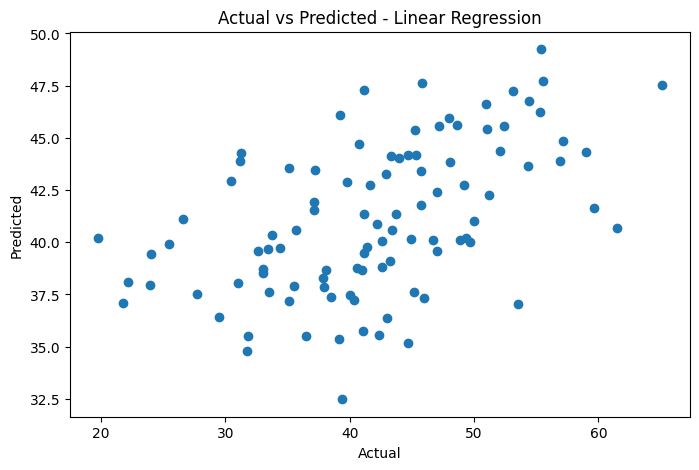

In [ ]:
plt.scatter(y_test, y_pred_lin)
plt.title("Actual vs Predicted - Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

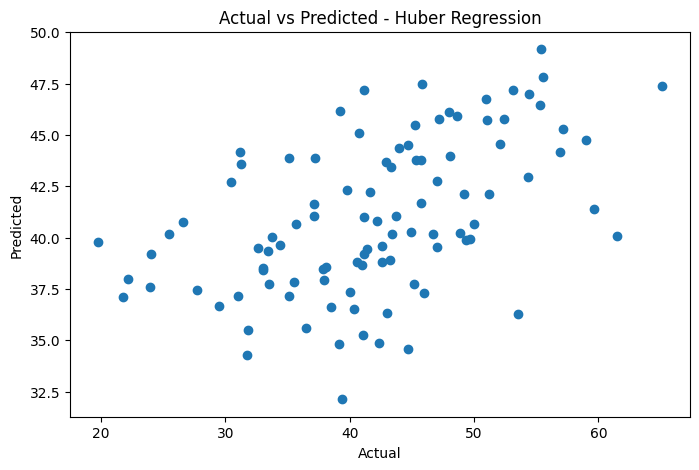

In [ ]:
plt.scatter(y_test, y_pred_huber)
plt.title("Actual vs Predicted - Huber Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

### Interpretasi Prediksi
- Apakah prediksi mengikuti nilai aktual?  
Jika dilihat pada hasil visualisasi, nilai prediksi beberapa sudah mengikuti nilai aktual, namun masih cukup lemah untuk prediksi, terlihat bahwa titik-titik memang cenderung naik ke kanan yang menandakan adanya korelasi positif, namun titik-titiknya masih terlalu menyebar, di mana model hanya bisa menangkap tren besar tapi gagal menebak nilai tepatnya.

- Di bagian mana model gagal?  
Jika dilihat pada visualisasi model gagal menangkap pola ketika nilai rendah yaitu pada sumbu Actual sekitar 20–30, model cenderung memprediksi nilai yang terlalu tinggi dimana titik berada di atas garis imajiner diagonal. Selanjutnya pada nilai tinggi yang terlihat pada sumbu actual di atas 50–60, model gagal mencapai angka tersebut dan justru memprediksi nilai yang jauh lebih rendah. Sehingga, model hanya memprediksi di area rata-rata sehingga gagal memprediksi lonjakan atau penurunan energi yang drastis.  

- Apakah ada pola error tertentu?  
Terlihat ada penyempitan rentang prediksi sebagai dampak noise tinggi, baik pada linear regression dan huber regression, dimana artinya bukan karena outlier yang ekstrem melainkan ada pola non linear yang ada, tapi tidak bisa ditangkap oleh model.  

Baik model linear/huber memiliki keterbatasan tidak mampu menangkap pola non linear, sehingga hasil prediksi cukup lemah dibandingkan hasil aktual.

## O. Analisis Kritis dan Refleksi

Jawab secara argumentatif:

1. Apa tiga temuan utama dari analisis Anda?  
a. Suhu dan kelembaban adalah fitur prediktor utama yang mempengaruhi target. Dimana, hal ini dibuktikan pada analisis korelasi yang menunjukkan bahwa humidity dan temperatur memiliki korelasi Pearson tertinggi dengan energy_consumption.  
b. Terdapat hubungan non-linear yang tidak dapat ditangkap oleh model, yang menghasilkan nilai R2 rendah serta nilai MAE dan RMSE yang tinggi. Baik pada model linear regression maupun huber regression. Hal ini merupakan keterbatasan model linear.  
c. Pada model dataset ini terdapat outlier, missing value yang perlu ditangani agar tidak terjadi bias, dan hasil akan lebih akurat.

2. Apa risiko jika hasil model langsung dipakai untuk pengambilan keputusan?  
Apabila model langsung dipakai untuk pengambilan kesimpulan maka    
a. Resiko ketidakakuratan hasil : Model akan menghasilkan nilai R2 yang lebih rendah dan MAE dan RMSE yang lebih tinggi, sehingga hasil yang diberikan model jauh dari kondisi aktual.
b. Model dilatih dengan data yang sudah di capping, sehingga tidak mampu memprediksi lonjakan energi saat terjadi acara besar atau kondisi ekstrem. Risiko yang terjadi adalah kesalahan alokasi anggaran energi pada hari-hari sibuk.  
c. Variabel student_count dan device_usage saling tumpang tindih. Tidak bisa melihat pengaruh satu variabel secara murni tanpa melibatkan variabel lainnya. Risiko yang terjadi adalah salah dalam mengambil kebijakan karena menganggap kedua variabel ini terpisah.  

3. Apakah hubungan yang ditemukan bersifat korelasional atau kausal?  
Hubungan yang ditemukan bersifat korelasional, karena berdasarkan hasil analisis yang kita lakukan diatas hasil hanya menunjukkan bahwa variabel-variabel tersebut bergerak bersamaan.  

4. Apa keterbatasan dataset Anda?  
a. Durasi yang diberikan hanya 500 jam atau sekitar 21 hari, tentunya dataset ini termasuk pendek untuk diambil kesimpulan mengenai konsumsi energi.  
b. Kurangnya variabel yang berhubungan secara langsung dengan variabel target contohnya seperti jenis gedung, kapasitas sistem HVAC, atau jadwal kuliah yang tidak tercermin dalam data.  
c. Sangat amat banyak noise yang terjadi, sehingga sulit bagi model statistik sederhana untuk mencapai akurasi tinggi.  

5. Jika diberi kesempatan memperbaiki analisis, apa yang akan Anda lakukan?  
a. Saya akan mentransformasi pola non linear yang tidak bisa ditangkap oleh model, untuk meningkatkan nilai r2, dimana ternyata pola ini juga sangat berefek pada konsumsi energi.  
b. Menggunakan algoritma yang lebih kompleks seperti Random Forest atau XGBoost yang lebih handal dalam menangkap hubungan non linear dan interaksi antar fitur tanpa perlu transformasi manual.  
c. Menerapkan Ridge Regression atau VIF analysis untuk mengurangi dampak multikolinearitas antara student_count dan device_usage.

## P. Log Keputusan Analitik

Isi tabel berikut:

| Tahap | Keputusan | Alasan |
|------|-----------|--------|
| Missing value | Imputasi Median | Distribusi student_count mendekati uniform, median lebih robust terhadap outlier dibanding mean, deletion akan membuang 10% data yang berharga |
| Outlier | Winsorization (IQR capping) | Outlier merepresentasikan kondisi nyata, tidak layak dihapus, sehingga capping membatasi pengaruh ekstrem tanpa menghilangkan informasi fitur lain pada baris tersebut |
| Scaling | One-Hot Encoding + drop_first | day_type bersifat nominal; drop_first mencegah dummy variable trap, interpretasi koefisien menjadi: selisih energi weekend vs weekday |
| Scaling/Transformasi | Tidak dilakukan | LinearRegression dan HuberRegressor tidak sensitif terhadap skala fitur; scaling diperlukan jika menggunakan regularized regression |
| Fitur model | 5 Fitur digunakan | Relevan secara domain dan statistik, multikolinearitas student_count-device_usage diakui sebagai keterbatasan |
| Model akhir | Linear Regression | Memberikan performa (R2, MAE, RMSE) yang sedikit lebih baik dibandingkan Huber Regression pada dataset ini. |
| Evaluasi Model | Diterima dengan Catatan | Sebagai identifikasi tren awal, model diterima. Namun, diperlukan perbaikan untuk menangkap pola non linear |

Lengkapi tabel dengan keputusan Anda sendiri.

## Q. Kesimpulan

Tuliskan kesimpulan akhir dalam 1–2 paragraf:
- Apa yang berhasil ditemukan?
- Model mana yang paling layak?
- Apakah hasil cukup kuat untuk mendukung keputusan?  

Berdasarkan analisis yang telah dilakukan, ditemukan bahwa variabel lingkungan seperti humidity dan temperature memiliki pengaruh paling dominan terhadap konsumsi energi di kampus, diikuti oleh device usage. Meskipun terdapat korelasi positif yang jelas antara student_count dan energy_consumption, ditemukan adanya hubungan non-linear yang tidak mampu ditangkap sepenuhnya oleh model linear dan huber. Selain itu, audit data menunjukkan adanya ketergantungan yang tinggi atau multikolinearitas antara jumlah mahasiswa dan perangkat yang aktif, serta keberadaan missing values sebesar 10% yang berhasil ditangani melalui imputasi median.

Model Linear Regression dinilai lebih layak dibandingkan Huber Regression untuk dataset ini, karena memberikan nilai R2 yang lebih tinggi (0.2322) serta tingkat kesalahan (MAE dan RMSE) yang lebih rendah. Namun, secara keseluruhan, hasil model ini belum cukup kuat untuk dijadikan basis pengambilan keputusan operasional yang kritis atau alokasi anggaran yang presisi. Hal ini disebabkan oleh rendahnya daya jelaskan model terhadap variansi target dan adanya error sistematis pada nilai-nilai ekstrem. Model ini lebih tepat digunakan sebagai instrumen identifikasi tren awal, di mana diperlukan pengembangan lebih lanjut melalui feature engineering atau penggunaan model non-linear untuk mencapai akurasi yang memadai.

Penggunaan AI : Digunakan untuk debug sintaks error, serta mencari teori mengenai model linear.   
Sumber :  
1. Linear Regression: Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.  
2. Wes McKinney. (2022). Python for Data Analysis. O'Reilly Media.
3. Gareth James, dkk. (2013). An Introduction to Statistical Learning: with Applications in R. Springer.


## Ketentuan Penting
1. Tidak cukup hanya menampilkan output kode.
2. Setiap tahap wajib disertai interpretasi.
3. Setiap keputusan preprocessing dan modeling wajib diberi alasan.
4. Jawaban generik tanpa keterkaitan dengan hasil aktual notebook akan dinilai rendah.
5. Fokus utama penilaian adalah kualitas penalaran, bukan sekadar angka performa.